In [1]:
# Cell 1 — install (then restart session)
!pip install -q transformers accelerate bitsandbytes Pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.2 MB/s eta 0:00:00


In [2]:
!pip install -q -U bitsandbytes>=0.46.1

In [1]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig
import torch

processor = LlavaNextProcessor.from_pretrained(
    "llava-hf/llava-v1.6-mistral-7b-hf"
)

# 4-bit config goes here instead
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = LlavaNextForConditionalGeneration.from_pretrained(
    "llava-hf/llava-v1.6-mistral-7b-hf",
    torch_dtype=torch.float16,
    quantization_config=quantization_config
)
print("Model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

The image processor of type `LlavaNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded.


In [2]:
# Cell 3 — caption function
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

def caption_image(image_source, prompt="Describe this image in detail."):
    if isinstance(image_source, str) and image_source.startswith("http"):
        response = requests.get(image_source, timeout=10)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    elif isinstance(image_source, str):
        image = Image.open(image_source).convert("RGB")
    else:
        image = image_source.convert("RGB")

    full_prompt = f"[INST] <image>\n{prompt} [/INST]"

    inputs = processor(
        full_prompt, image, return_tensors="pt"
    ).to("cuda")

    output = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False
    )

    full_text = processor.decode(output[0], skip_special_tokens=True)
    caption   = full_text.split("[/INST]")[-1].strip()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image); ax.axis("off")
    words = caption.split()
    lines = [" ".join(words[j:j+10]) for j in range(0, len(words), 10)]
    ax.set_title("\n".join(lines), fontsize=10, pad=10, linespacing=1.6)
    plt.tight_layout(); plt.show()
    print(f"Caption: {caption}")
    return caption

Saving 438106 8.jpg to 438106 8.jpg


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


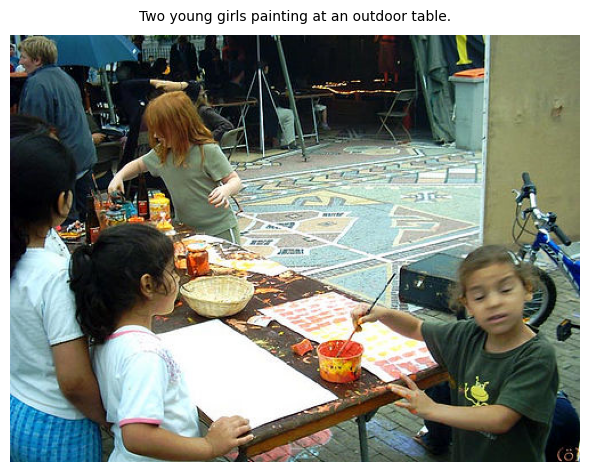

Caption: Two young girls painting at an outdoor table.


In [4]:
from google.colab import files
from io import BytesIO
from PIL import Image

uploaded = files.upload()

for fname, data in uploaded.items():
    image = Image.open(BytesIO(data)).convert("RGB")

    full_prompt = "[INST] <image>\nLook at this image and generate a single, concise image caption that describes the main subject and scene. The caption should: Be one sentence only, Start with 'a' or 'an' or 'two' etc. (like standard COCO captions), Describe only what is visually present, Be between 8-15 words. Do not explain your reasoning. Output only the caption. [/INST]"

    inputs = processor(
        images=image,
        text=full_prompt,
        return_tensors="pt"
    ).to("cuda")

    output = model.generate(**inputs, max_new_tokens=150, do_sample=False)

    full_text = processor.decode(output[0], skip_special_tokens=True)
    caption   = full_text.split("[/INST]")[-1].strip()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image); ax.axis("off")
    words = caption.split()
    lines = [" ".join(words[j:j+10]) for j in range(0, len(words), 10)]
    ax.set_title("\n".join(lines), fontsize=10, pad=10, linespacing=1.6)
    plt.tight_layout(); plt.show()
    print(f"Caption: {caption}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saving 3014609505.jpg to 3014609505.jpg


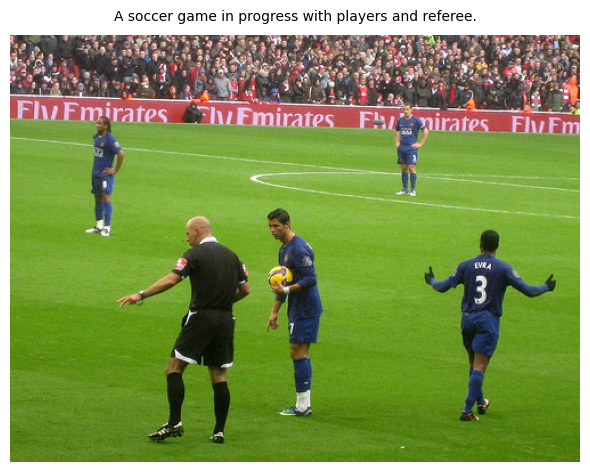

Caption: A soccer game in progress with players and referee.


In [6]:
from google.colab import files
from io import BytesIO
from PIL import Image

uploaded = files.upload()

for fname, data in uploaded.items():
    image = Image.open(BytesIO(data)).convert("RGB")

    full_prompt = "[INST] <image>\nLook at this image and generate a single, concise image caption that describes the main subject and scene. The caption should: Be one sentence only, Start with 'a' or 'an' or 'two' etc. (like standard COCO captions), Describe only what is visually present, Be between 8-15 words. Do not explain your reasoning. Output only the caption. [/INST]"

    inputs = processor(
        images=image,
        text=full_prompt,
        return_tensors="pt"
    ).to("cuda")

    output = model.generate(**inputs, max_new_tokens=150, do_sample=False)

    full_text = processor.decode(output[0], skip_special_tokens=True)
    caption   = full_text.split("[/INST]")[-1].strip()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image); ax.axis("off")
    words = caption.split()
    lines = [" ".join(words[j:j+10]) for j in range(0, len(words), 10)]
    ax.set_title("\n".join(lines), fontsize=10, pad=10, linespacing=1.6)
    plt.tight_layout(); plt.show()
    print(f"Caption: {caption}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saving 3483392163.jpg to 3483392163 (1).jpg


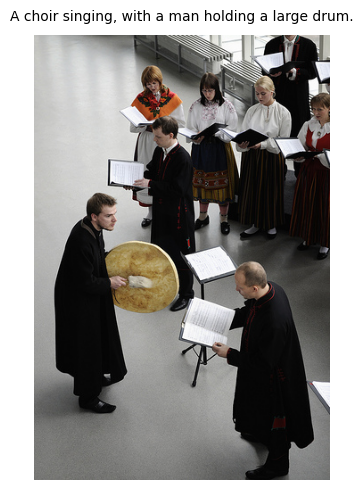

Caption: A choir singing, with a man holding a large drum.


In [7]:
from google.colab import files
from io import BytesIO
from PIL import Image

uploaded = files.upload()

for fname, data in uploaded.items():
    image = Image.open(BytesIO(data)).convert("RGB")

    full_prompt = "[INST] <image>\nLook at this image and generate a concise image caption that describes the main subject and scene. The caption should: Be one sentence only, Start with 'a' or 'an' or 'two' etc. (like standard COCO captions), Describe only what is visually present, Be between 8-15 words. Do not explain your reasoning. Output only the caption. [/INST]"

    inputs = processor(
        images=image,
        text=full_prompt,
        return_tensors="pt"
    ).to("cuda")

    output = model.generate(**inputs, max_new_tokens=150, do_sample=False)

    full_text = processor.decode(output[0], skip_special_tokens=True)
    caption   = full_text.split("[/INST]")[-1].strip()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image); ax.axis("off")
    words = caption.split()
    lines = [" ".join(words[j:j+10]) for j in range(0, len(words), 10)]
    ax.set_title("\n".join(lines), fontsize=10, pad=10, linespacing=1.6)
    plt.tight_layout(); plt.show()
    print(f"Caption: {caption}")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Saving 3012222153.jpg to 3012222153.jpg


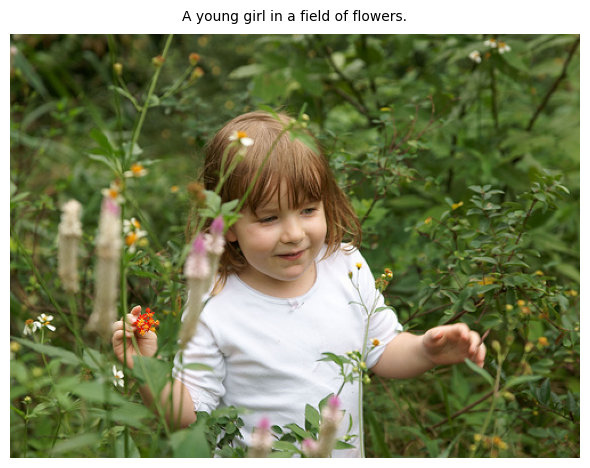

Caption: A young girl in a field of flowers.


In [8]:
from google.colab import files
from io import BytesIO
from PIL import Image

uploaded = files.upload()

for fname, data in uploaded.items():
    image = Image.open(BytesIO(data)).convert("RGB")

    full_prompt = "[INST] <image>\nLook at this image and generate a single, concise image caption that describes the main subject and scene. The caption should: Be one sentence only, Start with 'a' or 'an' or 'two' etc. (like standard COCO captions), Describe only what is visually present, Be between 8-15 words. Do not explain your reasoning. Output only the caption. [/INST]"

    inputs = processor(
        images=image,
        text=full_prompt,
        return_tensors="pt"
    ).to("cuda")

    output = model.generate(**inputs, max_new_tokens=150, do_sample=False)

    full_text = processor.decode(output[0], skip_special_tokens=True)
    caption   = full_text.split("[/INST]")[-1].strip()

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(image); ax.axis("off")
    words = caption.split()
    lines = [" ".join(words[j:j+10]) for j in range(0, len(words), 10)]
    ax.set_title("\n".join(lines), fontsize=10, pad=10, linespacing=1.6)
    plt.tight_layout(); plt.show()
    print(f"Caption: {caption}")